In [1]:
import sys, os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["PYTORCH_USE_CUDA_DSA"] = "1"
import numpy as np
import torch
import yaml
import pickle as pk
import numpy as np
import sys,os
import readgadget
import MAS_library as MASL
import pickle as pk
import readfof
import matplotlib
import readfof
import sys, os
import numpy as np
import pickle as pk 
# from nbodykit.lab import *
import h5py as h5
import numpy as np
import Pk_library as PKL
import MAS_library as MASL
import yaml
# from train_dtai_LRES_MDIFF import *
# from model_enc_dec import *
from tqdm import tqdm
import gc
import matplotlib.pyplot as pl
%matplotlib inline


In [2]:
# nvocab = 64
# grid = 32
# DS_RES_POS_FAC = 4
# grid_sbox = 8
# subsel_type = 'all'
# Mstar_cut = 12.7
# add_space_token = False
# BoxSize = 1000.
# isim_fid = 247

# ldir = '/work/hdd/bdne/spandey3/quijote_data/halo_gotham_data/LH'
# savefname_dmo_fields = f'{ldir}/DMO_fields_ng32/DMO_fields_grid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_32768_MAS_CIC_nsnaps_2.pkl'
# df = pk.load(open(savefname_dmo_fields,'rb'))
# dmo_fields_all = torch.moveaxis(torch.tensor(df['dmo_fields_all']).to(torch.float16), -1, 1)

# savefname_gals = f'{ldir}/halo_props_ng32/halo_props_snap_73_grid_{nvocab//DS_RES_POS_FAC}_isim_{isim_fid}_nrandsubsel_32768_nvocab{nvocab}_spacetoken_{add_space_token}_xMv1Dc_{Mstar_cut}.pkl'    
# df = pk.load(open(savefname_gals,'rb'))
# story_full_12p7 = df['story_full']




In [40]:
dtype = 'bfloat16'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

# Ndevices = 2
grid_sbox = 8
BoxSize = 1000.
grid = 32
# grid_sbox = 32
nvocab = 64
nrand_sel_box = 8192
subsamp_ds = 1
ds_fac_here = 1
# ds_type_here = 'random'
ds_type_here = 'seq'
# rand_seed_dsfac = 0
rand_seed_dsfac = 0
# add_space_token = False
# Mstar_cut = 8.5
# Ndevices = 24 
# Mstar_cut = 12.7/


Ndevices = 16
Mstar_cut = 13.3

# Mstar_cut = 13.3
DS_RES_POS_FAC = 4


In [41]:
rank = 0
device_id = 0
sdir = '/work/hdd/bdne/spandey3/quijote_data/halo_gotham_data/process_split'
savefname = f'{sdir}/SPLIT_DMO_DATA_{Ndevices}_gpus_density3Dgrid_{grid_sbox}_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}.h5'
with h5.File(savefname, 'r') as f:
    ind_sel_train = np.arange(f[f'dm_train_dev_{rank}'][:].shape[0])
    ind_sel_val = np.arange(f[f'dm_val_dev_{rank}'][:].shape[0])

    print(f"ind_sel_train = {ind_sel_train.shape}, ind_sel_val = {ind_sel_val.shape}", flush=True)
    dm_train_gpu = f[f'dm_train_dev_{rank}'][:][ind_sel_train]
    dm_val_gpu = f[f'dm_val_dev_{rank}'][:][ind_sel_val]
    grid_size = int(f['grid'][()])
f.close()



ind_sel_train = (761856,), ind_sel_val = (172032,)


In [42]:
add_space_token = False
savefname = f'{sdir}/SPLIT_HALO_DATA_{Ndevices}_gpus_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}_grid_{nvocab//DS_RES_POS_FAC}_nvocab{nvocab}_spacetoken_{add_space_token}_xMv1Dc_{Mstar_cut}.h5'
with h5.File(savefname, 'r') as f:
    x_train_gpu = f[f'x_train_dev_{rank}'][:][ind_sel_train]
    y_train_gpu = f[f'y_train_dev_{rank}'][:][ind_sel_train]
    mask_train_gpu = f[f'mask_train_dev_{rank}'][:][ind_sel_train]
    params_train_gpu = f[f'params_train_dev_{rank}'][:][ind_sel_train]

    x_val_gpu = f[f'x_val_dev_{rank}'][:][ind_sel_val]
    params_val_gpu = f[f'params_val_dev_{rank}'][:][ind_sel_val]

    nvocab_total = f['nvocab_total'][()]
    start_token = f['start_token'][()]
    pad_token = int(f['pad_token'][()])
    end_token = f['end_token'][()]
    max_sentence_length = f['max_sentence_length'][()]  

    print(x_train_gpu.shape, x_val_gpu.shape)
f.close()




(761856, 181) (172032, 181)


In [43]:
xall = (np.linspace(0, BoxSize/grid, nvocab//DS_RES_POS_FAC + 1))
xarray = 0.5 * (xall[1:] + xall[:-1])
yarray = np.copy(xarray)
zarray = np.copy(xarray)
bins_digitize = np.linspace(-1e-3, 1, nvocab)


In [18]:
# max_new_tokens = df['max_sentence_length']
# nvocab_tot = df['end_token'] + 1


# # bins_digitize.insert(0, -1)
# # bins_digitize = np.insert(bins_digitize, 0, -1)


# start_token = df['start_token']
# pad_token = df['pad_token']
# end_token =  df['end_token']
# space_token = df['space_token']


In [44]:
# prop_min = df['prop_min']
# prop_max = df['prop_max']

prop_min = [12.7, -0.6, 1.]
prop_max = [15.3, 0.6, 15.]


dim_pos = 3
dim_prop = len(prop_min)   
dim_tot = dim_pos + dim_prop


# BoxSize = 1000.
# grid = 8
xmin = BoxSize/grid/2

MAS     = 'NGP'  #mass-assigment scheme
# grid_Pk = 16
# threads = 10

def get_prop_pos(X_val, grid=1):
    pos_infer_all = []
    prop_infer_all = []
    
    for jx in range(grid):
        for jy in range(grid):
            for jz in range(grid):
                sentence_here = X_val[jx, jy, jz]
                if add_space_token:
                    ntokens_per_halo = dim_tot + 1
                else:
                    ntokens_per_halo = dim_tot
                ind_start_token = 0
                if end_token in sentence_here:
                    ind_end_token = np.where(sentence_here == end_token)[0]
                    try:
                        Nhalos_here = ((ind_end_token - ind_start_token - 1) / ntokens_per_halo)[0]
                    except:
                        print(ind_end_token, ind_start_token, ntokens_per_halo)
                    if (int(Nhalos_here) - Nhalos_here) != 0:
                        Nhalos_here = ((ind_end_token - ind_start_token ) / ntokens_per_halo)[0]
                        # print(Nhalos_here, Nhalos_here2, 'Nhalos_here is not an integer')
                        # pass
                    if (int(Nhalos_here) - Nhalos_here) != 0:
                        print(Nhalos_here, 'Nhalos_here is not an integer')
                    else:
                        if Nhalos_here > 0:
                            for jh in range(int(Nhalos_here)):
                                try:
                                    prop_all = np.zeros(dim_prop)        
                                    for jp in range(dim_prop):
                                        # noise_val = np.random.uniform(-delta_bin/2, delta_bin/2)
                                        noise_val = 0.0
                                        bin_val_jp = sentence_here[ind_start_token + jh*ntokens_per_halo + 1 + jp]
                                        # try:
                                            # if jh == 0:
                                        prop_all[jp] = prop_min[jp] + (prop_max[jp] - prop_min[jp]) * (bins_digitize[bin_val_jp] + noise_val)
                                            # else:
                                            #     prop_all[jp] = 0.0
                                        # except:
                                            # pass

                                    coord_x = (xarray[sentence_here[ind_start_token + jh*ntokens_per_halo + dim_prop + 1]] + (BoxSize/grid)*jx) % BoxSize
                                    coord_y = (yarray[sentence_here[ind_start_token + jh*ntokens_per_halo + dim_prop + 2]] + (BoxSize/grid)*jy) % BoxSize
                                    coord_z = (zarray[sentence_here[ind_start_token + jh*ntokens_per_halo + dim_prop + 3]] + (BoxSize/grid)*jz) % BoxSize
                                    pos_infer_all.append([coord_x, coord_y, coord_z])
                                            # print(sentence_here)
                                    prop_infer_all.append(prop_all)
    
                                except Exception as e:
                                    print(jx, jy, jz, jh, e)
                                    pass
                                    # print(sentence_here[ind_start_token], ntokens_per_halo)
                else:           
                    print('End token not found')
                    pass
    
    pos_infer_all = np.array(pos_infer_all)
    prop_infer_all = np.array(prop_infer_all)
    return pos_infer_all, prop_infer_all

    

0 0 0 27 index 68 is out of bounds for axis 0 with size 16
(27, 3) (27, 3)


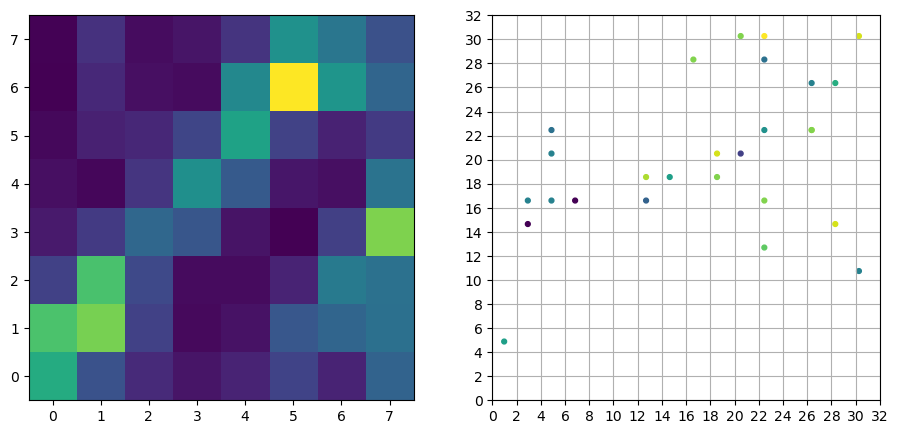

In [39]:
indp = 10010
pos_truth_all, prop_truth_all = get_prop_pos(y_train_gpu[indp,:][None, None, None, :], grid=1)
print(pos_truth_all.shape, prop_truth_all.shape)

fig, axs = pl.subplots(1, 2, figsize=(11,5))
axs[0].imshow(np.sum(dm_train_gpu[indp, 0, :, :, :], axis=-1), origin='lower')
axs[1].scatter(pos_truth_all[:,0], pos_truth_all[:,1],  s=12.0, c=prop_truth_all[:,0], cmap='viridis')
axs[1].grid()
axs[1].set_xlim(0, 32)
axs[1].set_ylim(0, 32)
# set x and y ticks to be 0, 2, ..., 32:
_ = axs[1].set_xticks(np.arange(0, 33, 2))
_ = axs[1].set_yticks(np.arange(0, 33, 2))


0 0 0 0 index 20 is out of bounds for axis 0 with size 16
0 0 0 4 index 68 is out of bounds for axis 0 with size 16
(3, 3) (3, 3)


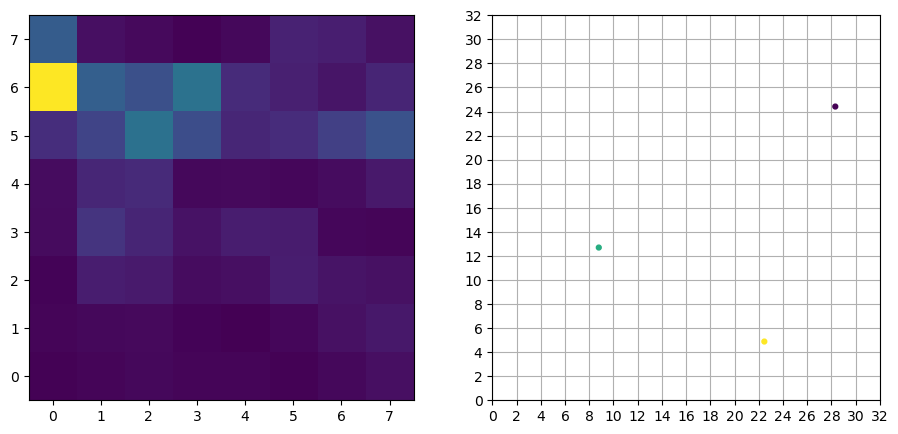

In [51]:
indp = 12089
pos_truth_all, prop_truth_all = get_prop_pos(y_train_gpu[indp,:][None, None, None, :], grid=1)
print(pos_truth_all.shape, prop_truth_all.shape)

fig, axs = pl.subplots(1, 2, figsize=(11,5))
axs[0].imshow(np.sum(dm_train_gpu[indp, 0, :, :, :], axis=-1), origin='lower')
axs[1].scatter(pos_truth_all[:,0], pos_truth_all[:,1],  s=12.0, c=prop_truth_all[:,0], cmap='viridis')
axs[1].grid()
axs[1].set_xlim(0, 32)
axs[1].set_ylim(0, 32)
# set x and y ticks to be 0, 2, ..., 32:
_ = axs[1].set_xticks(np.arange(0, 33, 2))
_ = axs[1].set_yticks(np.arange(0, 33, 2))


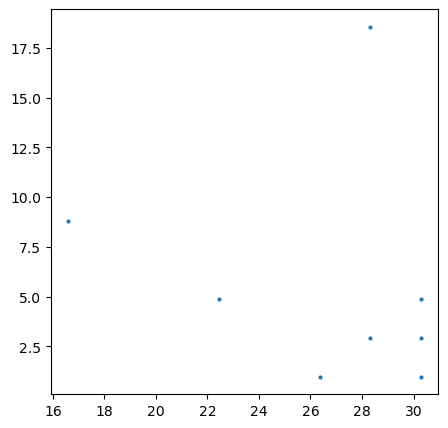

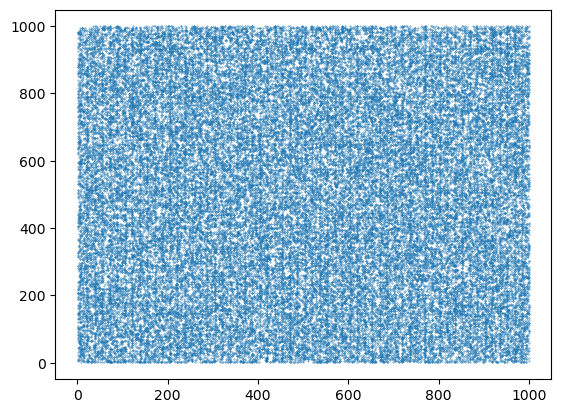

In [8]:
# pos_truth_all.shape, prop_truth_all.shape, len(pos_truth_all), len(prop_truth_all)
pl.figure()
pl.scatter(pos_truth_all[::10,0], pos_truth_all[::10,1],  s=0.1)




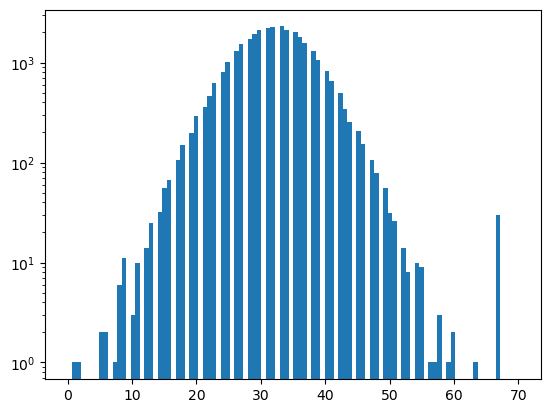

In [8]:
jp = 2
pl.figure()
_ = pl.hist(story_full_12p7[:,jp], bins=100, range=(0, 70))
# _ = pl.hist(story_full_12p7[:,jp], bins=69, range=(0,69))
# _ = pl.hist(story_full_13p3[:,jp], bins=100, range=(0, 70), histtype='step')
# pl.axvline(pad_token, color='k', linestyle='--')
# pl.axvline(end_token, color='r', linestyle='--')
pl.yscale('log')


In [14]:
prop_truth_all.shape

(634401, 3)

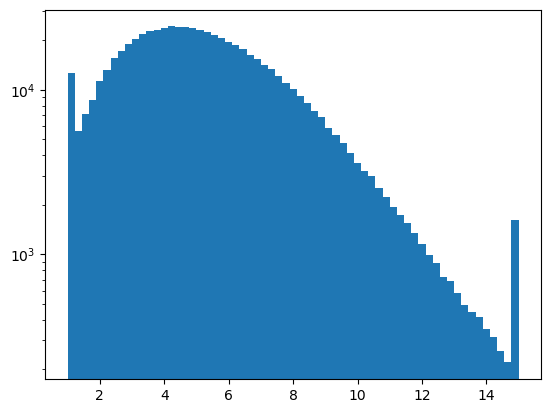

In [28]:
# jp = 0
pl.figure()
# _ = pl.hist(prop_truth_all[:,0], bins=63, range=(12.7, 15.3))
# _ = pl.hist(prop_truth_all[:,1], bins=63, range=(-0.6, 0.6))
_ = pl.hist(prop_truth_all[:,2], bins=63, range=(1, 15))
# _ = pl.hist(story_full_12p7[:,jp], bins=69, range=(0,69))
# _ = pl.hist(story_full_13p3[:,jp], bins=100, range=(0, 70), histtype='step')
# pl.axvline(pad_token, color='k', linestyle='--')
# pl.axvline(end_token, color='r', linestyle='--')
pl.yscale('log')


In [9]:
Mstar_cut = 13.3
savefname_gals = f'{ldir}/halo_props_ng32/halo_props_snap_73_grid_{nvocab//DS_RES_POS_FAC}_isim_{isim_fid}_nrandsubsel_32768_nvocab{nvocab}_spacetoken_{add_space_token}_xMv1Dc_{Mstar_cut}.pkl'    
df = pk.load(open(savefname_gals,'rb'))
story_full_13p3 = df['story_full']


In [24]:
pad_token = df['pad_token']
end_token = df['end_token']


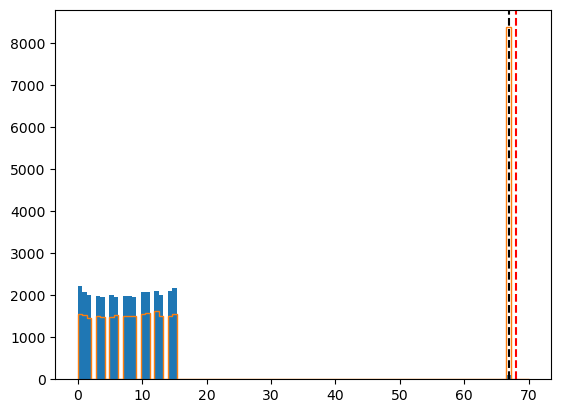

In [28]:
jp = 10
pl.figure()
_ = pl.hist(story_full_12p7[:,jp], bins=100, range=(0, 70))
_ = pl.hist(story_full_13p3[:,jp], bins=100, range=(0, 70), histtype='step')
pl.axvline(pad_token, color='k', linestyle='--')
pl.axvline(end_token, color='r', linestyle='--')


In [26]:
pad_token, end_token



(67, 68)